In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
#Dimensiones de la imagen a crear
ancho = 300
alto = 200
font = cv2.FONT_HERSHEY_SIMPLEX

**Tarea 1: Ajedrez**

(800, 800, 3)


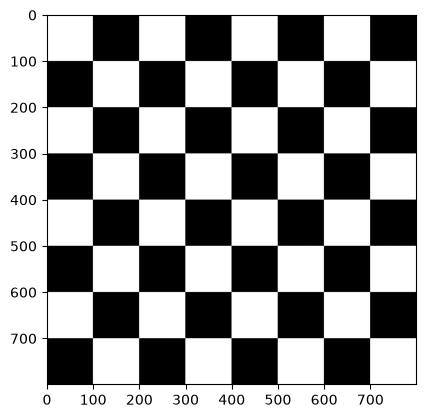

In [2]:
# NUESTRO CÓDIGO --------------------------------------------------------
#Crea una imagen con tres planos
color_img = np.zeros((800,800,3), dtype = np.uint8)
#Dimensiones
print(color_img.shape)

for i in range(8):
    y_inicio = i * 100
    y_fin = (i + 1) * 100

    if i % 2 == 0:
        for j in range(0, 800, 200):
            color_img[y_inicio:y_fin, j:j+100] = 255
    else:
        for j in range(100, 800, 200):
            color_img[y_inicio:y_fin, j:j+100] = 255

#Visualiza con matplotlib (sin especificar el mapa de color gris)
plt.imshow(color_img) 
plt.show()

# CÓDIGO DE GEMINI -----------------------------------------------------------

# 1. Crear una matriz base de 8x8 con el patrón de ajedrez (0 y 255)
# (i + j) % 2 == 0 genera True en casillas pares (blancas)
#filas, columnas = np.indices((8, 8))
#tablero_8x8 = ((filas + columnas) % 2 == 0).astype(np.uint8) * 255

# 2. Redimensionar/Escalar cada casilla a 100x100 píxeles usando np.repeat
# Esto genera directamente la matriz de 800x800
#color_img = np.repeat(np.repeat(tablero_8x8, 100, axis=0), 100, axis=1)

# Dimensiones (800, 800)
#print(color_img.shape)

# 3. Visualizar en escala de grises
#plt.imshow(color_img, cmap="gray")
#plt.show()

**Tarea 2: Mondrian:**


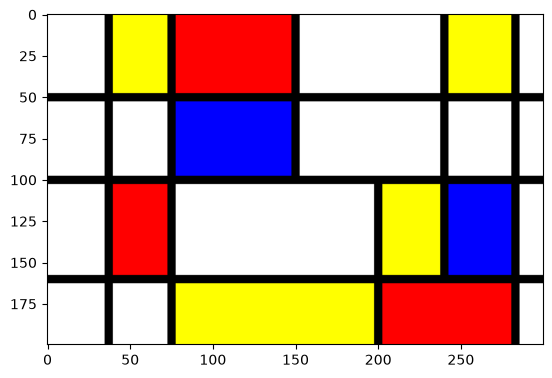

True

In [3]:
#Fondo blanco
color_img = np.full((alto, ancho, 3), 255, dtype=np.uint8)

#Líneas negras
#2 Lineas negras verticales a la izquierda
cv2.line(color_img,(int(ancho/8),0),(int(ancho/8),alto),(0,0,0),3)
cv2.line(color_img,(int(ancho/4),0),(int(ancho/4),alto),(0,0,0),3)
#2 Linea negra central a medias
cv2.line(color_img,(int(ancho/2),0),(int(ancho/2),int(alto/2)),(0,0,0),3)
cv2.line(color_img,(int(ancho/1.5),alto),(int(ancho/1.5),int(alto/2)),(0,0,0),3)
#2 Lineas negras verticales a la derecha
cv2.line(color_img,(int(ancho/1.25),0),(int(ancho/1.25),int(alto/1.25)),(0,0,0),3)
cv2.line(color_img,(int(ancho/1.06),0),(int(ancho/1.06),int(alto)),(0,0,0),3)
#2 Lineas negras horizontales
cv2.line(color_img,(0, int(alto / 2)),(ancho, int(alto / 2)),(0,0,0),3)
cv2.line(color_img,(0, int(alto / 4)),(ancho, int(alto / 4)),(0,0,0),3)
cv2.line(color_img,(0, int(alto / 1.25)),(ancho, int(alto / 1.25)),(0,0,0),3)

#Rectángulos amarillos
cv2.rectangle(color_img,(40,0),(72,47),(255,255,0),-1)
cv2.rectangle(color_img,(243,0),(280,47),(255,255,0),-1)
cv2.rectangle(color_img,(203,157),(237,103),(255,255,0),-1)
cv2.rectangle(color_img,(78,200),(197,163),(255,255,0),-1)

#Rectángulos rojos
cv2.rectangle(color_img,(78,0),(147,47),(255,0,0),-1)
cv2.rectangle(color_img,(40,157),(72,103),(255,0,0),-1)
cv2.rectangle(color_img,(203,200),(280,163),(255,0,0),-1)

#Rectángulos azules
cv2.rectangle(color_img,(78,97),(147,53),(0,0,255),-1)
cv2.rectangle(color_img,(243,157),(280,103),(0,0,255),-1)

plt.imshow(color_img) 
plt.show()
#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**Tarea 3: Detección de píxeles más oscuros y claros** 

In [2]:
vid = cv2.VideoCapture(0)

while(True):
    ret, frame = vid.read()

    # Convertir a escala de grises para comprarlar la luminosidad
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    #Encontrar los valores y las posiciones mins y max
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(gray)

    # Circulo negro para el pixel mas oscuro (min_loc)
    cv2.circle(frame, min_loc, 8, (0, 0, 0), 2)

    # Circulo blanco para el pixel mas claro (max_loc)
    cv2.circle(frame, max_loc, 8, (255, 255, 255), 2)

    cv2.putText(frame, "Menor Intensidad", (min_loc[0] + 10, min_loc[1] + 10),  font, 0.5, (0, 0, 0), 1)
    cv2.putText(frame, "Mayor Intensidad", (max_loc[0] + 10, max_loc[1] + 10), font, 0.5, (255, 255, 255), 1)

    cv2.imshow('Cam', frame)

    # Detenemos pulsado ESC
    if cv2.waitKey(1) == 27:
        break

vid.release()
cv2.destroyAllWindows()

**Tarea 4: Pop art propio**

In [ ]:
vid = cv2.VideoCapture(0)

#Paleta Pop Art
azul = np.array([200, 20, 20], dtype=np.uint8)
rojo  = np.array([20, 20, 240], dtype=np.uint8)
amarillo = np.array([10, 240, 255], dtype=np.uint8)

while(True):
    ret, frame = vid.read()

    frame = cv2.resize(frame, (640, 480))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    #Suaviza texturas para que queden manchas planas como pintura serigrafiada
    suave = cv2.medianBlur(gray, 7)

    #Lienzo base Pop Art
    pop = np.zeros(frame.shape, dtype=frame.dtype)
    pop[:] = amarillo

    #Asignar los bloques de color plano segun la luminosidad
    pop[suave < 170] = rojo
    pop[suave < 85]  = azul

    #Lineas negras
    bordes = cv2.adaptiveThreshold(suave, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 2)
    bordes_bgr = cv2.cvtColor(bordes, cv2.COLOR_GRAY2BGR)

    #Superponer lineas negras a los colores
    resultado = cv2.bitwise_and(pop, bordes_bgr)

    cv2.imshow('Cam',resultado)

    if cv2.waitKey(1) == 27:
        break

vid.release()
cv2.destroyAllWindows()